# Encountered Severity 

In [141]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
import rioxarray
from rasterio.plot import show
import seaborn as sns

from prescribed.utils import prepare_template


# We use California Albers Equal Area Conic for all our analyses, so we need to reproject the MTBS data to match that CRS.
ca_crs = "EPSG:3310"

# Make all plots to be Helvetica Neue
plt.rcParams["font.family"] = "Helvetica Neue"

# Data path
data_path = "s3://wildfire-smoke-wapo"

## 0. Prepare template and MTBS data (1 sq-km grid for California) 

In [144]:
# Open template
grid_template = prepare_template(
    os.path.join(data_path, "geoms/templates/template.tif")
)

# Get MTBS data for CA alone
mtbs = gpd.read_file(
    os.path.join(data_path, "geoms/mtbs_perims_DD_updated/mtbs_perims_DD.shp")
).to_crs(ca_crs)
mtbs_ca = mtbs[mtbs["Event_ID"].str.startswith("CA")]

# Load severity data
dnbr = pd.read_feather(
    os.path.join(data_path, "processed/dnbr_gee_inmediate/dnbr_long.feather")
)

# Merge severity data with MTBS to get fire info
dnbr_mtbs = pd.merge(
    dnbr,
    mtbs_ca[["Event_ID", "Incid_Name", "Ig_Date"]],
    left_on="event_id",
    right_on="Event_ID",
    how="left",
)

# Make dnbr spatial aware
dnbr_mtbs = gpd.GeoDataFrame(
    dnbr_mtbs,
    geometry=gpd.points_from_xy(dnbr_mtbs.lon, dnbr_mtbs.lat),
    crs=ca_crs,
)

## 1. Find previous burns within a speicifc fire

In [123]:
# Get grid ids for a fire
fire_id = "CA3966012280920200817"  # August complex
grids_fire = dnbr_mtbs[(dnbr_mtbs["event_id"] == fire_id)]["grid_id"].tolist()

# Check past from grids that were affected by the Dixie Fire
previous_treats = dnbr_mtbs[
    (dnbr_mtbs["grid_id"].isin(grids_fire))
    & (dnbr_mtbs["event_id"] != fire_id)
    & (dnbr_mtbs["dnbr"] > 0)
    & (dnbr_mtbs["dnbr"] < 270)
]

# Keep the ones inside the polygon and not the closed ones
previous_treats = previous_treats[
    previous_treats.geometry.intersects(
        mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.unary_union
    )
]

# Calculate time difference between the previous treatments and the fire in years
previous_treats["time_diff"] = (
    pd.to_datetime(
        dnbr_mtbs[dnbr_mtbs["event_id"] == fire_id]["Ig_Date"].iloc[0]
    )
    - pd.to_datetime(previous_treats["Ig_Date"])
).dt.days / 365.25

/tmp/ipykernel_3812728/13442020.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.unary_union


## 2. Plot past treatments in the Dixie fire

/tmp/ipykernel_3812728/4265702245.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.unary_union


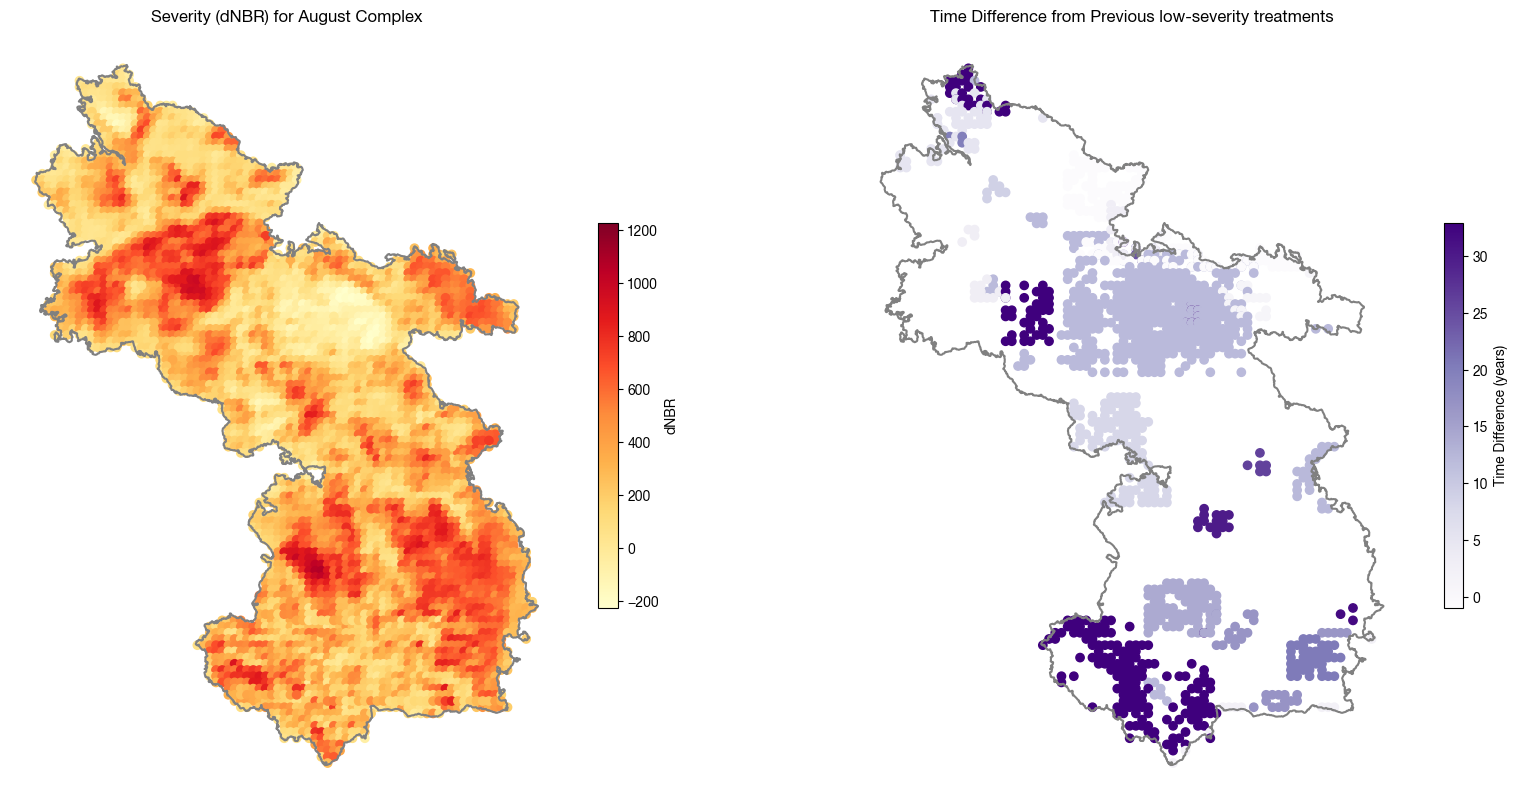

In [124]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.boundary.plot(
    ax=ax[0], color="gray", label="August Complex"
)
mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.boundary.plot(
    ax=ax[1], color="gray", label="August Complex"
)
# Plot severity for the fire after removing the adjacent pixels
clean_fire = dnbr_mtbs[
    (dnbr_mtbs["event_id"] == fire_id)
    & (
        dnbr_mtbs["geometry"].intersects(
            mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.unary_union
        )
    )
]

clean_fire.plot(
    ax=ax[0],
    column="dnbr",
    cmap="YlOrRd",
    legend=True,
    vmax=dnbr_mtbs["dnbr"].max(),
    legend_kwds={"label": "dNBR", "shrink": 0.5},
)

# The previous treatments
previous_treats.plot(
    ax=ax[1],
    column="time_diff",
    cmap="Purples",
    legend=True,
    legend_kwds={"label": "Time Difference (years)", "shrink": 0.5},
)

# Label the plots
ax[0].set_title("Severity (dNBR) for August Complex")
ax[1].set_title("Time Difference from Previous low-severity treatments")

# Make it nice
ax[0].set_axis_off()
ax[1].set_axis_off()

## 3. Histograms

/home/topcat/.local/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Text(0, 0.5, 'Density')

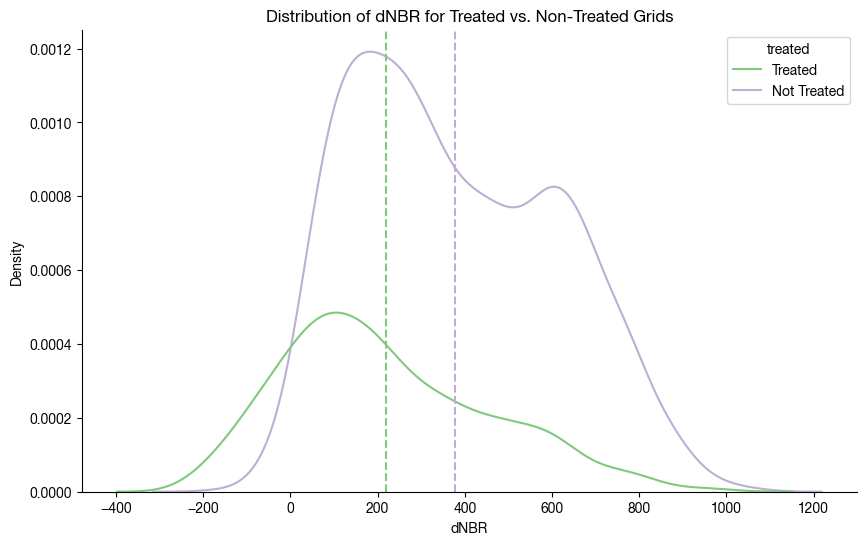

In [125]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram of treated vs. non-treated
clean_fire["treated"] = clean_fire["grid_id"].isin(previous_treats["grid_id"]).map({True: "Treated", False: "Not Treated"})

sns.kdeplot(
    data=clean_fire,
    x="dnbr",
    hue="treated",
    palette=["#7fc97f", "#beaed4"],
    ax=ax,
)

# Add vertical bar for the mean dNBR of treated and non-treated
mean_treated = clean_fire[clean_fire["treated"] == "Treated"]["dnbr"].mean()
mean_non_treated = clean_fire[clean_fire["treated"] == "Not Treated"]["dnbr"].mean()
ax.axvline(
    mean_treated,
    color="#7fc97f",
    linestyle="--",
    label=f"Treated Mean: {mean_treated:.1f}",
)
ax.axvline(
    mean_non_treated,
    color="#beaed4",
    linestyle="--",
    label=f"Non-Treated Mean: {mean_non_treated:.1f}",
)
#ax.legend()

# Despine the plot
sns.despine()

ax.set_title("Distribution of dNBR for Treated vs. Non-Treated Grids")
ax.set_xlabel("dNBR")
ax.set_ylabel("Density")

# Other data sources

## 1. Severity data (raw raster @ 30m resolution)

In [ ]:
ds = rioxarray.open_rasterio(os.path.join(data_path, f"raw/dnbr/dnbr_gee_inmediate/{fire_id}.tif"))

# Mask it so we just get the polygon
ds_masked = ds.rio.clip(
    mtbs_ca[mtbs_ca["Event_ID"] == fire_id].geometry.values, mtbs_ca.crs, drop=False
)

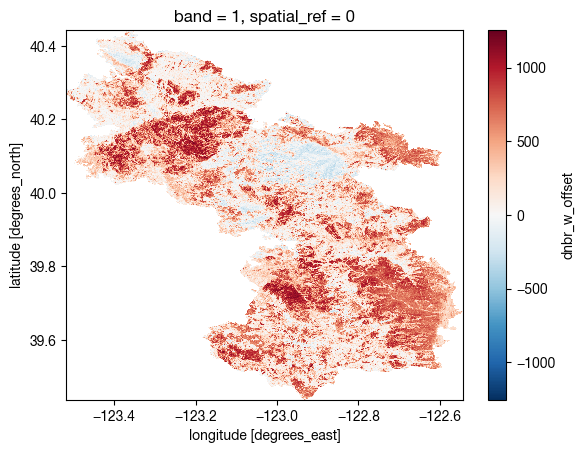

In [136]:
ds_masked.plot()